[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/arvidl/BMED365-2026/blob/main/Lab5-Comp-Mod/notebooks/01-action-potentials.ipynb)

# 01 — Action Potentials and the Hodgkin-Huxley Model

**BMED365 – Computational Medicine (Lab 5)**

_Arvid Lundervold w/ Claude (Anthropic) & Grok (xAI) — 2025-02-22_<br>
_Updated: 2026-02-15_  (Cursor 2.4.37 with Claude Opus 4.6)

---

## 1. Motivation & Learning Objectives

### Why study the action potential?

The **action potential** is the fundamental unit of communication in the nervous system. Every thought you think, every movement you make, every sensation you perceive — all depend on the rapid, precisely orchestrated electrical impulses that travel along neurons. Understanding the action potential is therefore central to understanding the brain itself.

In 1952, Alan Hodgkin and Andrew Huxley published a series of landmark papers that provided the first quantitative, biophysical model of the action potential. Their work on the **squid giant axon** — a remarkably large nerve fiber ideal for electrophysiological experiments — resulted in a set of nonlinear ordinary differential equations that accurately reproduce the shape, timing, and threshold behavior of real action potentials.

The **Hodgkin-Huxley (HH) model** is widely considered one of the greatest achievements in mathematical biology. It earned Hodgkin and Huxley the **Nobel Prize in Physiology or Medicine in 1963** and laid the groundwork for the entire field of **computational neuroscience**.

### What you will learn

In this notebook you will:

1. **Understand** the biological basis of the action potential — what happens at the level of ion channels in the cell membrane
2. **Appreciate** the historical context — how voltage-clamp experiments on squid giant axons led to a mathematical revolution
3. **Master** the mathematical formulation of the Hodgkin-Huxley model — the equivalent circuit, the coupled ODEs, and the gating kinetics
4. **Implement** the model in Python and simulate action potentials numerically
5. **Visualize** and interpret the dynamics of membrane potential, gating variables, and ionic currents
6. **Explore** clinical and scientific implications — from anesthetics to cardiac arrhythmias to neural prosthetics

## 2. Historical Context: The Squid, the Scientists, and the Nobel Prize

### The quest to understand nerve impulses

The electrical nature of nerve signals was suspected since Luigi Galvani's experiments in the 1780s, but it took nearly two centuries to develop a quantitative understanding. Key milestones include:

| Year | Milestone | Scientists |
|------|-----------|-----------|
| 1791 | Discovery of "animal electricity" | Luigi **Galvani** |
| 1850s | Measurement of nerve impulse velocity (~30 m/s) | Hermann von **Helmholtz** |
| 1902 | Membrane theory of nerve excitation | Julius **Bernstein** |
| 1939 | First intracellular recording from squid giant axon | Hodgkin & Huxley |
| 1949 | Development of voltage-clamp technique | Cole & Marmont; Hodgkin, Huxley & Katz |
| 1952 | Publication of the Hodgkin-Huxley model | Hodgkin & Huxley |
| 1963 | Nobel Prize in Physiology or Medicine | Hodgkin, Huxley & Eccles |

### Why the squid?

The **giant axon** of the North Atlantic squid (_Loligo_) is up to **1 mm in diameter** — about 100 to 1000 times thicker than a typical mammalian axon. This enormous size made it possible to:
- Insert electrodes *inside* the axon
- Measure membrane potential directly
- Apply the **voltage-clamp technique** to control membrane voltage and measure ionic currents independently

<img src="https://upload.wikimedia.org/wikipedia/commons/1/19/Giant_Axon_of_Squid_%2814356033761%29.jpg" alt="Squid giant axon research" width="400"/>

*Researcher examining giant squid axon fibers at Woods Hole, Massachusetts. NIH researchers such as Dr. Kenneth Cole and Dr. Tasaki conducted pioneering work on axon electrophysiology here. Source: NIH History Office / Wikimedia Commons (public domain).*

### The voltage-clamp revolution

The key experimental innovation was the **voltage clamp**: a feedback amplifier circuit that holds the membrane potential at a chosen value (the "command voltage") while measuring the current that flows through the membrane. By systematically varying the command voltage and using ion-substitution experiments, Hodgkin and Huxley were able to:

1. **Separate** the total membrane current into sodium, potassium, and leak components
2. **Characterize** the voltage- and time-dependence of each ionic conductance
3. **Fit** mathematical expressions to the experimental data
4. **Reconstruct** the action potential by solving the resulting differential equations — by hand, using a mechanical calculator!

> *"We were lucky in having a preparation \[the squid giant axon\] with which we could do experiments that were not possible with other nerve fibres."* — Alan Hodgkin

### The 1952 papers

Hodgkin and Huxley published five consecutive papers in the *Journal of Physiology* in 1952:
1. Measurement of membrane currents (H&H, 1952a)
2. The components of membrane conductance (H&H, 1952b)
3. Sodium and potassium conductance changes (H&H, 1952c)
4. The inactivation process (H&H, 1952d)
5. **A quantitative description of membrane current and its application to conduction and excitation in nerve** (H&H, 1952e) — the full model

The fifth paper presented the complete mathematical model and showed that it could reproduce: the shape of the action potential, its threshold, the refractory period, propagation velocity, repetitive firing, and many other experimentally observed phenomena.

In [14]:
from IPython.display import Image, display, HTML

# Display a schematic of the voltage-clamp setup
display(HTML('''
<figure style="text-align:center; margin: 20px 0;">
<img src="https://upload.wikimedia.org/wikipedia/commons/thumb/e/e5/Voltage_clamp.svg/960px-Voltage_clamp.svg.png"
     alt="Voltage-clamp schematic" width="500"/>
<figcaption style="font-size:0.9em; color:#555; margin-top:8px;">
<b>Figure 1.</b> Schematic of the voltage-clamp technique. A feedback amplifier injects current to keep
the membrane potential at the command voltage, while a separate electrode measures the required current.
<br/><i>Source: Wikimedia Commons (CC BY-SA 3.0).</i>
</figcaption>
</figure>
'''))

## 3. The Action Potential: Biological Background

### What is an action potential?

An **action potential** (AP) is a brief, all-or-nothing reversal of the electrical potential across a neuron's cell membrane. At rest, the inside of the neuron is about **−65 to −70 mV** relative to the outside (the **resting membrane potential**). During an action potential, the membrane potential rapidly swings to about **+30 to +40 mV** and then returns to rest — all within about **1–2 milliseconds**.

### The five phases

The action potential can be divided into five distinct phases:

| Phase | Description | Key mechanism |
|-------|-------------|---------------|
| **1. Resting state** | Membrane at ~−65 mV | Na⁺ and K⁺ channels mostly closed; leak channels maintain resting potential |
| **2. Depolarization** | Rapid rise to ~+40 mV | Voltage-gated Na⁺ channels open → Na⁺ rushes in |
| **3. Peak / Overshoot** | Membrane potential peaks | Na⁺ channels begin to inactivate |
| **4. Repolarization** | Return toward resting potential | Na⁺ channels inactivate; K⁺ channels open → K⁺ flows out |
| **5. Hyperpolarization** | Brief undershoot below rest | K⁺ channels still open; membrane temporarily more negative than rest |

### Ion channels: the molecular machinery

The action potential depends on two main types of **voltage-gated ion channels** embedded in the cell membrane:

- **Voltage-gated Na⁺ channels**: Have two gates — an *activation gate* (fast, controlled by gating variable $m$) and an *inactivation gate* (slow, controlled by $h$). The channel conducts only when both gates are open.
- **Voltage-gated K⁺ channels**: Have a single *activation gate* (controlled by $n$), which opens more slowly than the Na⁺ activation gate.
- **Leak channels**: Always open, providing a small background conductance that helps maintain the resting potential.

### Check Your Understanding: The Action Potential

**Q1.** During which phase of the action potential is the membrane potential *positive* (inside more positive than outside)?

<details>
<summary>Click to reveal answer</summary>

During the **depolarization** and **peak/overshoot** phases (phases 2 and 3). The membrane potential crosses 0 mV as Na⁺ ions rush in through open voltage-gated Na⁺ channels, reaching approximately +30 to +40 mV at the peak. This reversal of polarity is transient — it lasts less than 1 ms.

</details>

---

**Q2.** Why can't the membrane potential reach the Na⁺ equilibrium potential ($E_\text{Na} = +50$ mV) during an action potential, even though Na⁺ channels are open?

<details>
<summary>Click to reveal answer</summary>

Several factors prevent the membrane from reaching $E_\text{Na}$:
1. **Na⁺ channel inactivation** — the $h$ gate begins closing even while the membrane is depolarizing, reducing Na⁺ conductance before equilibrium is reached
2. **K⁺ channel activation** — the $n$ gates are opening (albeit slowly), allowing an opposing outward K⁺ current
3. **Leak current** — a small but persistent leak conductance also opposes full depolarization
4. **Capacitive effects** — the membrane capacitance takes time to charge

The peak of the action potential (~+40 mV) is a *compromise* between the inward Na⁺ current and these opposing factors.

</details>

---

**Q3.** A patient receives a local anesthetic (e.g., lidocaine) at the dentist. Based on what you know about action potentials, what molecular target does this drug act on, and why does it block pain?

<details>
<summary>Click to reveal answer</summary>

Lidocaine blocks **voltage-gated Na⁺ channels** in sensory neurons. Without functional Na⁺ channels, the rapid depolarization phase (the $m$ gate activation) cannot occur, so action potentials are **not generated**. Since pain signals are carried as trains of action potentials from the periphery to the brain, blocking AP generation in local nerve fibers effectively eliminates pain sensation in that region. This is why it's called a *local* anesthetic — it only affects neurons near the injection site.

</details>

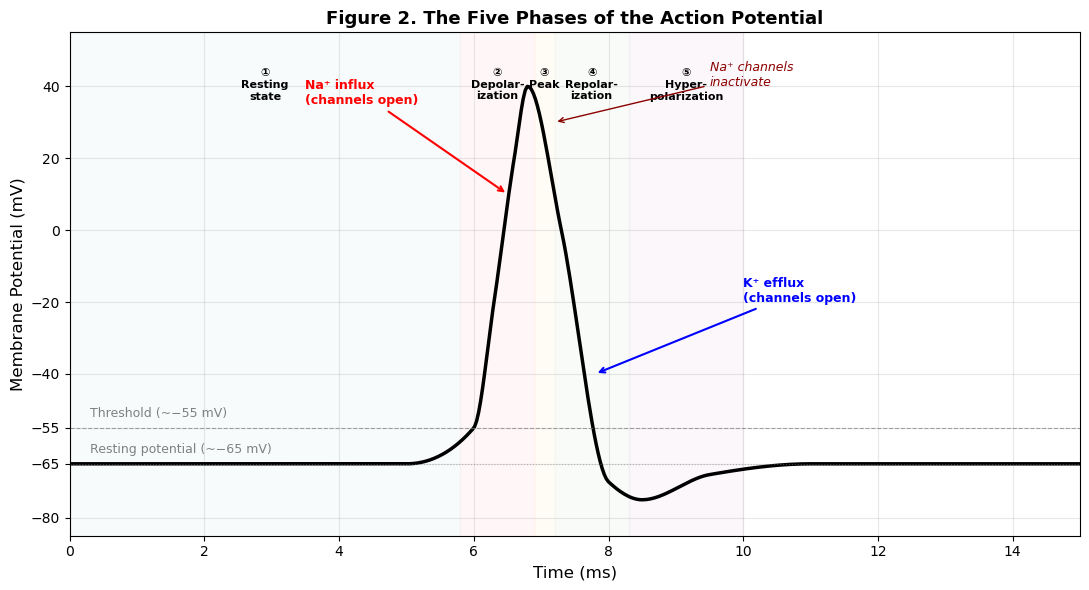

In [31]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# --- Programmatic illustration of an idealized action potential ---
fig, ax = plt.subplots(figsize=(11, 6))

# Create an idealized action potential shape using piecewise functions
t_ap = np.array([0, 5, 6, 6.3, 6.6, 6.8, 7.3, 8.0, 8.5, 9.5, 11, 15])
v_ap = np.array([-65, -65, -55, -20, 20, 40, 0, -70, -75, -68, -65, -65])

# Interpolate for smooth curve
from scipy.interpolate import PchipInterpolator
t_fine = np.linspace(0, 15, 500)
interp = PchipInterpolator(t_ap, v_ap)
v_fine = interp(t_fine)

ax.plot(t_fine, v_fine, 'k-', linewidth=2.5)

# Threshold line
ax.axhline(y=-55, color='gray', linestyle='--', linewidth=0.8, alpha=0.7)
ax.text(0.3, -52, 'Threshold (~−55 mV)', fontsize=9, color='gray')

# Resting potential line
ax.axhline(y=-65, color='gray', linestyle=':', linewidth=0.8, alpha=0.5)
ax.text(0.3, -62, 'Resting potential (~−65 mV)', fontsize=9, color='gray')

# Phase annotations with colored regions
phases = [
    (0, 5.8, -80, 50, '#e8f4f8', '①\nResting\nstate'),
    (5.8, 6.9, -80, 50, '#ffe6e6', '②\nDepolar-\nization'),
    (6.9, 7.2, -80, 50, '#fff3e0', '③\nPeak'),
    (7.2, 8.3, -80, 50, '#e8f5e9', '④\nRepolar-\nization'),
    (8.3, 10.0, -80, 50, '#f3e5f5', '⑤\nHyper-\npolarization'),
]

for t0, t1, ymin, ymax, color, label in phases:
    ax.axvspan(t0, t1, alpha=0.3, color=color)
    ax.text((t0 + t1) / 2, 45, label, ha='center', va='top', fontsize=8, fontweight='bold')

# Arrow annotations for Na+ and K+
ax.annotate('Na⁺ influx\n(channels open)', xy=(6.5, 10), xytext=(3.5, 35),
            fontsize=9, color='red', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='red', lw=1.5))

ax.annotate('K⁺ efflux\n(channels open)', xy=(7.8, -40), xytext=(10, -20),
            fontsize=9, color='blue', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='blue', lw=1.5))

ax.annotate('Na⁺ channels\ninactivate', xy=(7.2, 30), xytext=(9.5, 40),
            fontsize=9, color='darkred', style='italic',
            arrowprops=dict(arrowstyle='->', color='darkred', lw=1.0))

ax.set_xlabel('Time (ms)', fontsize=12)
ax.set_ylabel('Membrane Potential (mV)', fontsize=12)
ax.set_title('Figure 2. The Five Phases of the Action Potential', fontsize=13, fontweight='bold')
ax.set_xlim(0, 15)
ax.set_ylim(-85, 55)
ax.set_yticks([-80, -65, -55, -40, -20, 0, 20, 40])
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Scientific and Clinical Implications

Understanding the action potential and the Hodgkin-Huxley model has had far-reaching consequences in both basic science and clinical medicine:

### Neuroscience & Brain Function
- The HH model is the foundation of **computational neuroscience**. Modern large-scale brain simulations (e.g., the Blue Brain Project, the Human Brain Project) use HH-type models for individual neurons
- Understanding how networks of neurons generate complex behavior (perception, memory, motor control) begins with understanding the single-neuron action potential

### Pharmacology & Anesthetics
- **Local anesthetics** (e.g., lidocaine) work by blocking voltage-gated Na⁺ channels, preventing action potential propagation in pain-sensing neurons
- **Antiepileptic drugs** (e.g., carbamazepine, phenytoin) modulate Na⁺ or K⁺ channel kinetics to reduce excessive neuronal firing
- The HH model provides a quantitative framework for predicting how channel-blocking drugs will affect neural excitability

### Cardiac Electrophysiology
- The heart's electrical conduction system uses action potentials similar in principle (though different in detail) to those in neurons
- **Cardiac arrhythmias** can result from dysfunctional ion channels (channelopathies), and the HH framework has been extended to model cardiac cells (e.g., the Luo-Rudy, O'Hara-Rudy models)
- **Anti-arrhythmic drugs** are classified by which ion channels they target (the Vaughan-Williams classification)

### Neurological Disorders
- **Multiple sclerosis** — demyelination disrupts action potential propagation along axons
- **Epilepsy** — excessive, synchronized neuronal firing traced to ion channel dysfunction
- **Channelopathies** — genetic mutations in Na⁺, K⁺, or Ca²⁺ channels cause conditions like episodic ataxia, long QT syndrome, and familial hemiplegic migraine

### Neural Engineering & Prosthetics
- **Deep brain stimulation** for Parkinson's disease relies on understanding how electrical stimulation modulates action potentials
- **Cochlear implants** and **retinal prosthetics** must interface with neurons at the level of action potential generation
- **Brain-computer interfaces** record and decode patterns of action potentials

> *The Hodgkin-Huxley model remains, after more than 70 years, one of the most successful quantitative models in all of biology.*

## 5. The Hodgkin-Huxley Model: Conceptual Framework

### The membrane as an electrical circuit

Hodgkin and Huxley's key insight was to model the cell membrane as an **equivalent electrical circuit**:

- The **lipid bilayer** acts as a **capacitor** ($C_m$), storing charge across the membrane
- Each type of **ion channel** acts as a **variable conductance** (resistor) in parallel with the capacitor
- Each ionic conductance is in series with a **battery** (the Nernst/reversal potential for that ion)
- **External current** ($I_\text{ext}$) can be injected to stimulate the neuron

The total membrane current is the sum of capacitive current and ionic currents:

$$I_\text{total} = C_m \frac{dV}{dt} + I_\text{ionic}$$

This leads to the central equation of the HH model:

$$C_m \frac{dV}{dt} = I_\text{ext} - \underbrace{g_\text{Na}\, m^3 h\, (V - E_\text{Na})}_{I_\text{Na}} - \underbrace{g_\text{K}\, n^4\, (V - E_\text{K})}_{I_\text{K}} - \underbrace{g_\text{L}\, (V - E_\text{L})}_{I_\text{L}}$$

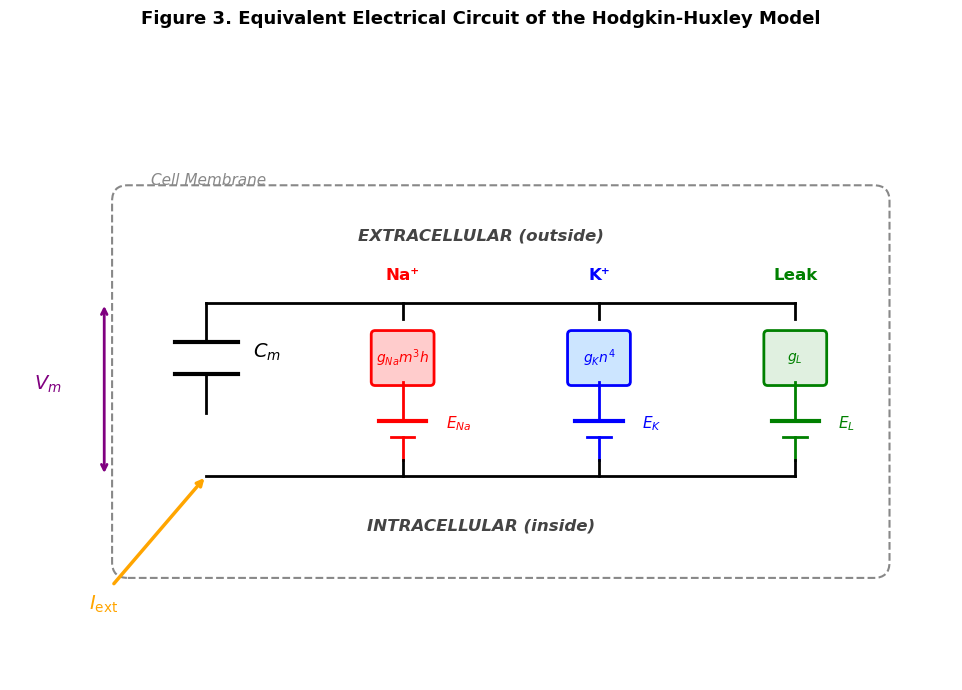

In [32]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch

fig, ax = plt.subplots(figsize=(12, 7))
ax.set_xlim(0, 12)
ax.set_ylim(0, 8)
ax.set_aspect('equal')
ax.axis('off')

# --- Draw the equivalent circuit ---

# Membrane capacitor
cap_x, cap_y = 2.5, 4.0
ax.plot([cap_x, cap_x], [cap_y + 0.8, cap_y + 0.3], 'k-', lw=2)
ax.plot([cap_x - 0.4, cap_x + 0.4], [cap_y + 0.3, cap_y + 0.3], 'k-', lw=3)
ax.plot([cap_x - 0.4, cap_x + 0.4], [cap_y - 0.1, cap_y - 0.1], 'k-', lw=3)
ax.plot([cap_x, cap_x], [cap_y - 0.1, cap_y - 0.6], 'k-', lw=2)
ax.text(cap_x + 0.6, cap_y + 0.1, r'$C_m$', fontsize=14, fontweight='bold')

# Na channel (variable resistor + battery)
na_x = 5.0
# Variable resistor (zigzag approx. as box)
rect_na = FancyBboxPatch((na_x - 0.35, cap_y - 0.2), 0.7, 0.6,
                          boxstyle="round,pad=0.05", facecolor='#ffcccc',
                          edgecolor='red', linewidth=2)
ax.add_patch(rect_na)
ax.text(na_x, cap_y + 0.1, r'$g_{Na}m^3h$', fontsize=10, ha='center', va='center',
        color='red', fontweight='bold')
# Battery
ax.plot([na_x, na_x], [cap_y - 0.2, cap_y - 0.7], 'r-', lw=2)
ax.plot([na_x - 0.3, na_x + 0.3], [cap_y - 0.7, cap_y - 0.7], 'r-', lw=3)
ax.plot([na_x - 0.15, na_x + 0.15], [cap_y - 0.9, cap_y - 0.9], 'r-', lw=2)
ax.plot([na_x, na_x], [cap_y - 0.9, cap_y - 1.2], 'r-', lw=2)
ax.text(na_x + 0.55, cap_y - 0.8, r'$E_{Na}$', fontsize=11, color='red')
# Wires
ax.plot([na_x, na_x], [cap_y + 0.6, cap_y + 0.8], 'k-', lw=2)
ax.plot([na_x, na_x], [cap_y - 1.2, cap_y - 1.4], 'k-', lw=2)
ax.text(na_x, cap_y + 1.1, 'Na⁺', fontsize=12, ha='center', color='red', fontweight='bold')

# K channel (variable resistor + battery)
k_x = 7.5
rect_k = FancyBboxPatch((k_x - 0.35, cap_y - 0.2), 0.7, 0.6,
                          boxstyle="round,pad=0.05", facecolor='#cce5ff',
                          edgecolor='blue', linewidth=2)
ax.add_patch(rect_k)
ax.text(k_x, cap_y + 0.1, r'$g_K n^4$', fontsize=10, ha='center', va='center',
        color='blue', fontweight='bold')
ax.plot([k_x, k_x], [cap_y - 0.2, cap_y - 0.7], 'b-', lw=2)
ax.plot([k_x - 0.3, k_x + 0.3], [cap_y - 0.7, cap_y - 0.7], 'b-', lw=3)
ax.plot([k_x - 0.15, k_x + 0.15], [cap_y - 0.9, cap_y - 0.9], 'b-', lw=2)
ax.plot([k_x, k_x], [cap_y - 0.9, cap_y - 1.2], 'b-', lw=2)
ax.text(k_x + 0.55, cap_y - 0.8, r'$E_K$', fontsize=11, color='blue')
ax.plot([k_x, k_x], [cap_y + 0.6, cap_y + 0.8], 'k-', lw=2)
ax.plot([k_x, k_x], [cap_y - 1.2, cap_y - 1.4], 'k-', lw=2)
ax.text(k_x, cap_y + 1.1, 'K⁺', fontsize=12, ha='center', color='blue', fontweight='bold')

# Leak channel (fixed resistor + battery)
l_x = 10.0
rect_l = FancyBboxPatch((l_x - 0.35, cap_y - 0.2), 0.7, 0.6,
                          boxstyle="round,pad=0.05", facecolor='#e0f0e0',
                          edgecolor='green', linewidth=2)
ax.add_patch(rect_l)
ax.text(l_x, cap_y + 0.1, r'$g_L$', fontsize=10, ha='center', va='center',
        color='green', fontweight='bold')
ax.plot([l_x, l_x], [cap_y - 0.2, cap_y - 0.7], 'g-', lw=2)
ax.plot([l_x - 0.3, l_x + 0.3], [cap_y - 0.7, cap_y - 0.7], 'g-', lw=3)
ax.plot([l_x - 0.15, l_x + 0.15], [cap_y - 0.9, cap_y - 0.9], 'g-', lw=2)
ax.plot([l_x, l_x], [cap_y - 0.9, cap_y - 1.2], 'g-', lw=2)
ax.text(l_x + 0.55, cap_y - 0.8, r'$E_L$', fontsize=11, color='green')
ax.plot([l_x, l_x], [cap_y + 0.6, cap_y + 0.8], 'k-', lw=2)
ax.plot([l_x, l_x], [cap_y - 1.2, cap_y - 1.4], 'k-', lw=2)
ax.text(l_x, cap_y + 1.1, 'Leak', fontsize=12, ha='center', color='green', fontweight='bold')

# Top wire (extracellular)
ax.plot([cap_x, l_x], [cap_y + 0.8, cap_y + 0.8], 'k-', lw=2)
ax.text(6.0, cap_y + 1.6, 'EXTRACELLULAR (outside)', fontsize=12, ha='center',
        fontweight='bold', style='italic', color='#444')

# Bottom wire (intracellular)
ax.plot([cap_x, l_x], [cap_y - 1.4, cap_y - 1.4], 'k-', lw=2)
ax.text(6.0, cap_y - 2.1, 'INTRACELLULAR (inside)', fontsize=12, ha='center',
        fontweight='bold', style='italic', color='#444')

# Membrane box
membrane_rect = FancyBboxPatch((1.5, cap_y - 2.5), 9.5, 4.6,
                                boxstyle="round,pad=0.2", facecolor='none',
                                edgecolor='#888', linewidth=1.5, linestyle='--')
ax.add_patch(membrane_rect)
ax.text(1.8, cap_y + 2.3, 'Cell Membrane', fontsize=11, color='#888', style='italic')

# External current arrow
ax.annotate('', xy=(cap_x, cap_y - 1.4), xytext=(cap_x - 1.2, cap_y - 2.8),
            arrowprops=dict(arrowstyle='->', color='orange', lw=2.5))
ax.text(cap_x - 1.5, cap_y - 3.1, r'$I_\mathrm{ext}$', fontsize=14, color='orange',
        fontweight='bold')

# Voltage label
ax.annotate('', xy=(1.2, cap_y + 0.8), xytext=(1.2, cap_y - 1.4),
            arrowprops=dict(arrowstyle='<->', color='purple', lw=2))
ax.text(0.3, cap_y - 0.3, r'$V_m$', fontsize=14, color='purple', fontweight='bold')

ax.set_title('Figure 3. Equivalent Electrical Circuit of the Hodgkin-Huxley Model',
             fontsize=13, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

## 6. Mathematical Formulation

### The coupled ODE system

The Hodgkin-Huxley model consists of **four coupled ordinary differential equations** — one for the membrane potential $V$ and three for the gating variables $m$, $h$, $n$:

#### Membrane potential:

$$C_m \frac{dV}{dt} = I_\text{ext} - g_\text{Na}\, m^3 h\, (V - E_\text{Na}) - g_\text{K}\, n^4\, (V - E_\text{K}) - g_\text{L}\, (V - E_\text{L})$$

#### Gating variables:

Each gating variable $x \in \{m, h, n\}$ follows first-order kinetics:

$$\frac{dx}{dt} = \alpha_x(V)\,(1 - x) - \beta_x(V)\,x$$

This can also be written in terms of steady-state activation $x_\infty(V)$ and time constant $\tau_x(V)$:

$$\frac{dx}{dt} = \frac{x_\infty(V) - x}{\tau_x(V)}$$

where $x_\infty(V) = \frac{\alpha_x}{\alpha_x + \beta_x}$ and $\tau_x(V) = \frac{1}{\alpha_x + \beta_x}$.

### Voltage-dependent rate constants

The rate constants $\alpha$ and $\beta$ for each gating variable are empirical functions fit to squid axon data:

| Variable | $\alpha_x(V)$ | $\beta_x(V)$ |
|----------|---------------|--------------|
| $m$ (Na⁺ activation) | $\frac{0.1\,(V + 40)}{1 - e^{-(V+40)/10}}$ | $4\,e^{-(V+65)/18}$ |
| $h$ (Na⁺ inactivation) | $0.07\,e^{-(V+65)/20}$ | $\frac{1}{1 + e^{-(V+35)/10}}$ |
| $n$ (K⁺ activation) | $\frac{0.01\,(V+55)}{1 - e^{-(V+55)/10}}$ | $0.125\,e^{-(V+65)/80}$ |

### Standard parameter values

| Parameter | Symbol | Value | Unit |
|-----------|--------|-------|------|
| Membrane capacitance | $C_m$ | 1.0 | µF/cm² |
| Na⁺ max. conductance | $g_\text{Na}$ | 120.0 | mS/cm² |
| K⁺ max. conductance | $g_\text{K}$ | 36.0 | mS/cm² |
| Leak conductance | $g_\text{L}$ | 0.3 | mS/cm² |
| Na⁺ reversal potential | $E_\text{Na}$ | +50.0 | mV |
| K⁺ reversal potential | $E_\text{K}$ | −77.0 | mV |
| Leak reversal potential | $E_\text{L}$ | −54.4 | mV |

### Understanding the gating exponents

Why $m^3 h$ and $n^4$? Hodgkin and Huxley interpreted these as reflecting **independent gating particles**:
- The Na⁺ channel requires **3 activation particles** ($m$) to be in the "open" position AND **1 inactivation particle** ($h$) to *not* be blocking → conductance ∝ $m^3 h$
- The K⁺ channel requires **4 activation particles** ($n$) → conductance ∝ $n^4$

Modern molecular biology has largely confirmed this picture: voltage-gated Na⁺ channels have 4 homologous domains (3 contribute to activation, 1 has the inactivation "ball-and-chain"), and K⁺ channels are tetramers of identical subunits.

### Check Your Understanding: The Mathematics

**Q4.** In the HH model, why does the Na⁺ current use $m^3 h$ while the K⁺ current uses $n^4$? What is the physical interpretation of these exponents?

<details>
<summary>Click to reveal answer</summary>

The exponents reflect **independent gating particles** (subunits) in the ion channels:

- **Na⁺ channel ($m^3 h$)**: The channel has **3 activation gates** ($m$) that must all be open, AND **1 inactivation gate** ($h$) that must not be blocking. The probability that all 3 activation gates are open is $m^3$ (since they're independent), and the probability the inactivation gate is open is $h$. So the overall open probability is $m^3 h$.

- **K⁺ channel ($n^4$)**: The channel has **4 identical activation gates** ($n$) that must all be open. The probability that all 4 are open is $n^4$.

This was a *theoretical prediction* by Hodgkin and Huxley in 1952! Decades later, molecular biology confirmed that K⁺ channels are indeed **tetramers** (4 subunits) and Na⁺ channels have **4 homologous domains** (3 contributing to activation, 1 to inactivation).

</details>

---

**Q5.** What happens to the gating variable $m$ if the membrane is suddenly stepped to a very depolarized voltage (e.g., +20 mV) and held there? Describe qualitatively what $\alpha_m$ and $\beta_m$ do.

<details>
<summary>Click to reveal answer</summary>

At $V = +20$ mV:
- $\alpha_m(V)$ becomes very **large** (fast opening rate)
- $\beta_m(V)$ becomes very **small** (slow closing rate)
- Therefore $m_\infty = \frac{\alpha_m}{\alpha_m + \beta_m} \approx 1$ (nearly all gates open)
- The time constant $\tau_m = \frac{1}{\alpha_m + \beta_m}$ is very **small** (fast kinetics)

So $m$ quickly approaches ~1.0 — the Na⁺ activation gates snap open almost instantly at depolarized voltages. This is what drives the explosive upstroke of the action potential.

</details>

---

**Q6. (DIY)** Using the steady-state formulas, calculate $m_\infty$, $h_\infty$, and $n_\infty$ at $V = 0$ mV. Which channels are mostly open? Which are mostly closed?

<details>
<summary>Click for hint</summary>

Use the formulas:
$$x_\infty(V) = \frac{\alpha_x(V)}{\alpha_x(V) + \beta_x(V)}$$

Plug in $V = 0$ mV to each $\alpha$ and $\beta$ function from the table in Section 6.

</details>

<details>
<summary>Click to reveal answer</summary>

At $V = 0$ mV:
- $\alpha_m(0) = \frac{0.1 \times 40}{1 - e^{-4}} \approx 4.08$, $\beta_m(0) = 4 e^{-65/18} \approx 0.108$ → $m_\infty \approx 0.97$
- $\alpha_h(0) = 0.07 e^{-65/20} \approx 0.0027$, $\beta_h(0) = \frac{1}{1+e^{3.5}} \approx 0.97$ → $h_\infty \approx 0.003$
- $\alpha_n(0) = \frac{0.01 \times 55}{1 - e^{-5.5}} \approx 0.55$, $\beta_n(0) = 0.125 e^{-65/80} \approx 0.056$ → $n_\infty \approx 0.91$

**Interpretation**: At 0 mV, Na⁺ activation ($m$) is nearly maximal, but Na⁺ **inactivation** ($h \approx 0$) has shut the channels down! K⁺ activation ($n$) is high. This is the state during **repolarization** — Na⁺ channels are inactivated while K⁺ channels are wide open.

</details>

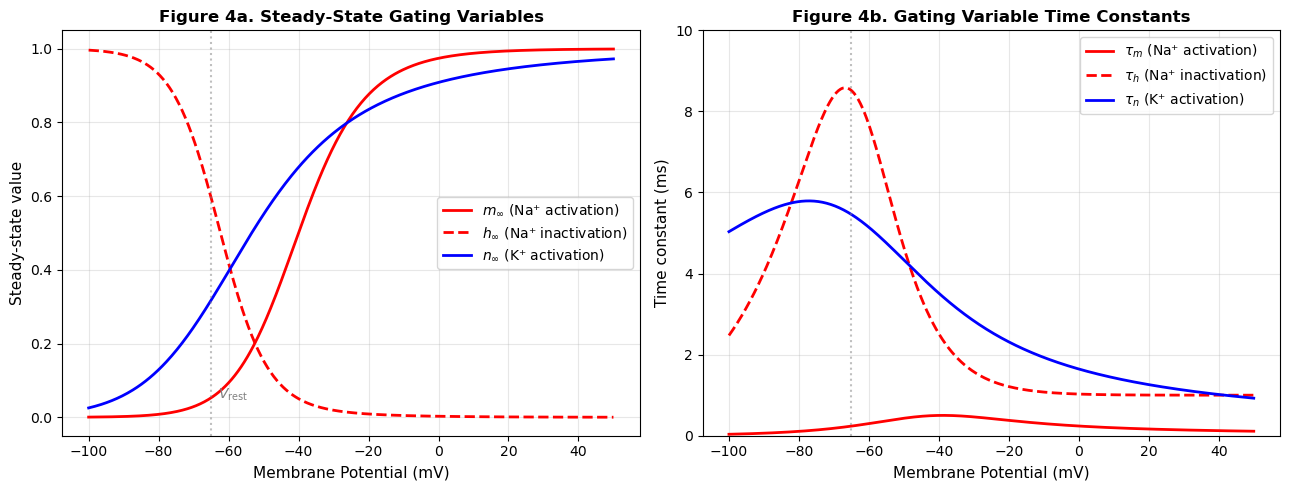

KEY OBSERVATIONS:
────────────────────────────────────────────────────────────
• m (Na⁺ activation) has the FASTEST kinetics (τ < 1 ms)
  → Na⁺ channels open very quickly upon depolarization
• h (Na⁺ inactivation) is SLOWER (τ ~ 1-8 ms)
  → Na⁺ channels close with a delay after opening
• n (K⁺ activation) is also SLOW (τ ~ 1-6 ms)
  → K⁺ channels open slowly, enabling repolarization
• This TIME SEPARATION is the key to the action potential!


In [33]:
import numpy as np
import matplotlib.pyplot as plt

# --- Voltage-dependent rate constants and steady-state curves ---

V = np.linspace(-100, 50, 500)

# Rate constants
def alpha_m(V): return 0.1 * (V + 40) / (1 - np.exp(-(V + 40) / 10))
def beta_m(V):  return 4.0 * np.exp(-(V + 65) / 18)
def alpha_h(V): return 0.07 * np.exp(-(V + 65) / 20)
def beta_h(V):  return 1.0 / (1 + np.exp(-(V + 35) / 10))
def alpha_n(V): return 0.01 * (V + 55) / (1 - np.exp(-(V + 55) / 10))
def beta_n(V):  return 0.125 * np.exp(-(V + 65) / 80)

# Steady-state values
m_inf = alpha_m(V) / (alpha_m(V) + beta_m(V))
h_inf = alpha_h(V) / (alpha_h(V) + beta_h(V))
n_inf = alpha_n(V) / (alpha_n(V) + beta_n(V))

# Time constants
tau_m = 1.0 / (alpha_m(V) + beta_m(V))
tau_h = 1.0 / (alpha_h(V) + beta_h(V))
tau_n = 1.0 / (alpha_n(V) + beta_n(V))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Steady-state activation/inactivation curves
ax1 = axes[0]
ax1.plot(V, m_inf, 'r-', lw=2, label=r'$m_\infty$ (Na⁺ activation)')
ax1.plot(V, h_inf, 'r--', lw=2, label=r'$h_\infty$ (Na⁺ inactivation)')
ax1.plot(V, n_inf, 'b-', lw=2, label=r'$n_\infty$ (K⁺ activation)')
ax1.axvline(x=-65, color='gray', linestyle=':', alpha=0.5)
ax1.text(-63, 0.05, r'$V_\mathrm{rest}$', fontsize=10, color='gray')
ax1.set_xlabel('Membrane Potential (mV)', fontsize=11)
ax1.set_ylabel('Steady-state value', fontsize=11)
ax1.set_title('Figure 4a. Steady-State Gating Variables', fontweight='bold')
ax1.legend(fontsize=10, loc='center right')
ax1.grid(True, alpha=0.3)
ax1.set_ylim(-0.05, 1.05)

# Time constants
ax2 = axes[1]
ax2.plot(V, tau_m, 'r-', lw=2, label=r'$\tau_m$ (Na⁺ activation)')
ax2.plot(V, tau_h, 'r--', lw=2, label=r'$\tau_h$ (Na⁺ inactivation)')
ax2.plot(V, tau_n, 'b-', lw=2, label=r'$\tau_n$ (K⁺ activation)')
ax2.axvline(x=-65, color='gray', linestyle=':', alpha=0.5)
ax2.set_xlabel('Membrane Potential (mV)', fontsize=11)
ax2.set_ylabel('Time constant (ms)', fontsize=11)
ax2.set_title('Figure 4b. Gating Variable Time Constants', fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.set_ylim(0, 10)

plt.tight_layout()
plt.show()

print("KEY OBSERVATIONS:")
print("─" * 60)
print("• m (Na⁺ activation) has the FASTEST kinetics (τ < 1 ms)")
print("  → Na⁺ channels open very quickly upon depolarization")
print("• h (Na⁺ inactivation) is SLOWER (τ ~ 1-8 ms)")
print("  → Na⁺ channels close with a delay after opening")
print("• n (K⁺ activation) is also SLOW (τ ~ 1-6 ms)")
print("  → K⁺ channels open slowly, enabling repolarization")
print("• This TIME SEPARATION is the key to the action potential!")

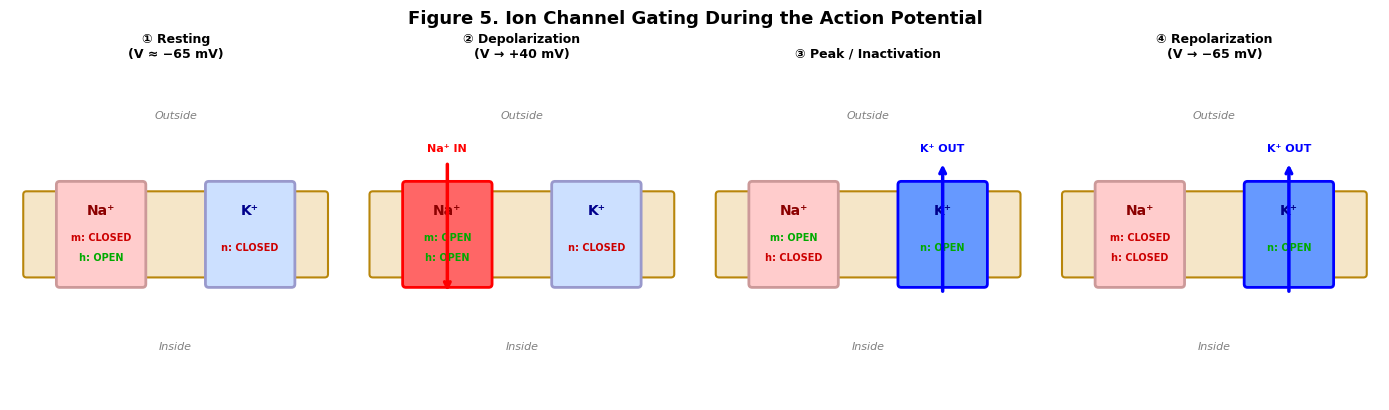

In [34]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
import numpy as np

fig, axes = plt.subplots(1, 4, figsize=(14, 4))

titles = ['① Resting\n(V ≈ −65 mV)', '② Depolarization\n(V → +40 mV)',
          '③ Peak / Inactivation', '④ Repolarization\n(V → −65 mV)']

# Channel states: (m-gate open?, h-gate open?, n-gate open?)
# Na+ channel: needs m=open AND h=open
# K+ channel: needs n=open
states = [
    {'m': False, 'h': True, 'n': False, 'na_flow': False, 'k_flow': False},  # Rest
    {'m': True, 'h': True, 'n': False, 'na_flow': True, 'k_flow': False},   # Depol
    {'m': True, 'h': False, 'n': True, 'na_flow': False, 'k_flow': True},  # Peak/Inactivation
    {'m': False, 'h': False, 'n': True, 'na_flow': False, 'k_flow': True},  # Repol
]

for idx, (ax, title, state) in enumerate(zip(axes, titles, states)):
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 10)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title(title, fontsize=9, fontweight='bold', pad=8)

    # Membrane (horizontal band)
    membrane = FancyBboxPatch((0.5, 3.8), 9, 2.4, boxstyle="round,pad=0.1",
                               facecolor='#f5e6c8', edgecolor='#b8860b', lw=1.5)
    ax.add_patch(membrane)

    # Na+ channel (left)
    na_color = '#ff6666' if state['na_flow'] else '#ffcccc'
    na_border = 'red' if state['na_flow'] else '#cc9999'
    na_ch = FancyBboxPatch((1.5, 3.5), 2.5, 3.0, boxstyle="round,pad=0.1",
                            facecolor=na_color, edgecolor=na_border, lw=2)
    ax.add_patch(na_ch)
    ax.text(2.75, 5.6, 'Na⁺', fontsize=10, ha='center', fontweight='bold', color='darkred')

    # m gate
    m_label = 'OPEN' if state['m'] else 'CLOSED'
    m_color = '#00aa00' if state['m'] else '#cc0000'
    ax.text(2.75, 4.8, f'm: {m_label}', fontsize=7, ha='center', color=m_color, fontweight='bold')

    # h gate
    h_label = 'OPEN' if state['h'] else 'CLOSED'
    h_color = '#00aa00' if state['h'] else '#cc0000'
    ax.text(2.75, 4.2, f'h: {h_label}', fontsize=7, ha='center', color=h_color, fontweight='bold')

    # Na+ flow arrow
    if state['na_flow']:
        ax.annotate('', xy=(2.75, 3.2), xytext=(2.75, 7.2),
                    arrowprops=dict(arrowstyle='->', color='red', lw=2.5))
        ax.text(2.75, 7.5, 'Na⁺ IN', fontsize=8, ha='center', color='red', fontweight='bold')

    # K+ channel (right)
    k_color = '#6699ff' if state['k_flow'] else '#cce0ff'
    k_border = 'blue' if state['k_flow'] else '#9999cc'
    k_ch = FancyBboxPatch((6.0, 3.5), 2.5, 3.0, boxstyle="round,pad=0.1",
                           facecolor=k_color, edgecolor=k_border, lw=2)
    ax.add_patch(k_ch)
    ax.text(7.25, 5.6, 'K⁺', fontsize=10, ha='center', fontweight='bold', color='darkblue')

    # n gate
    n_label = 'OPEN' if state['n'] else 'CLOSED'
    n_color = '#00aa00' if state['n'] else '#cc0000'
    ax.text(7.25, 4.5, f'n: {n_label}', fontsize=7, ha='center', color=n_color, fontweight='bold')

    # K+ flow arrow
    if state['k_flow']:
        ax.annotate('', xy=(7.25, 7.2), xytext=(7.25, 3.2),
                    arrowprops=dict(arrowstyle='->', color='blue', lw=2.5))
        ax.text(7.25, 7.5, 'K⁺ OUT', fontsize=8, ha='center', color='blue', fontweight='bold')

    # Labels
    ax.text(5, 8.5, 'Outside', fontsize=8, ha='center', color='gray', style='italic')
    ax.text(5, 1.5, 'Inside', fontsize=8, ha='center', color='gray', style='italic')

plt.suptitle('Figure 5. Ion Channel Gating During the Action Potential',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 7. Python Implementation of the Hodgkin-Huxley Model

Below we implement the HH model as a clean Python class and simulate the response to an injected current pulse. We then visualize:
1. The **membrane potential** $V(t)$ — the action potential itself
2. The **gating variables** $m(t)$, $h(t)$, $n(t)$ — the opening/closing of ion channels
3. The **ionic currents** $I_\text{Na}(t)$, $I_\text{K}(t)$, $I_\text{L}(t)$ — the flow of ions
4. The **ionic conductances** $g_\text{Na}\,m^3 h$ and $g_\text{K}\,n^4$ — how channel permeability changes

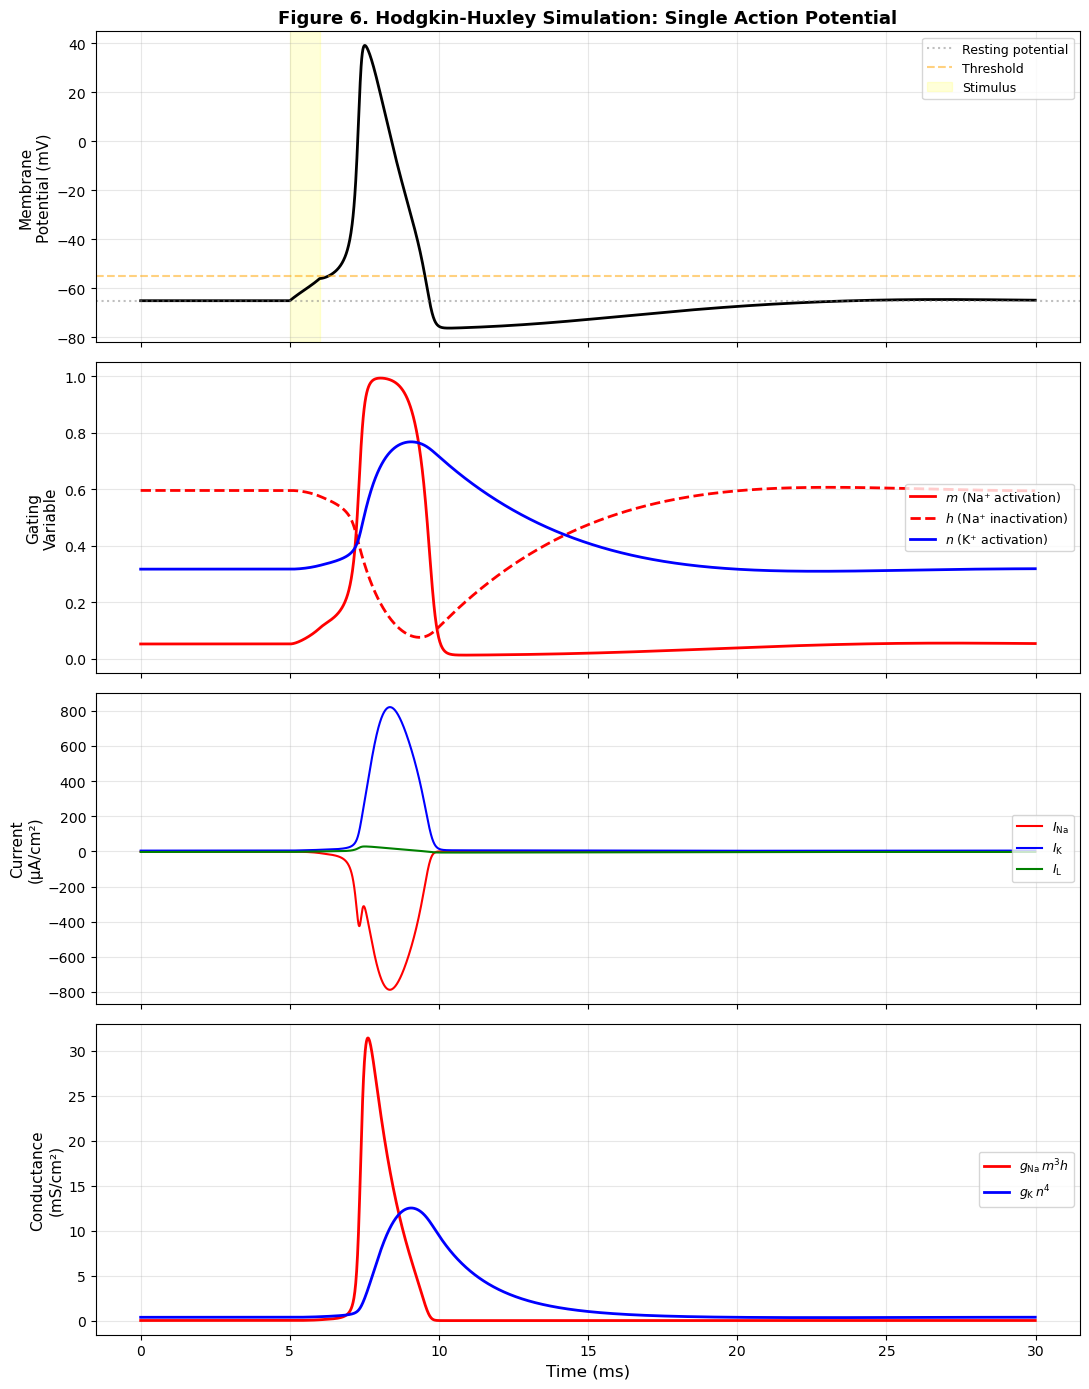

In [35]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt

class HodgkinHuxley:
    """Hodgkin-Huxley neuron model.

    Simulates the membrane potential dynamics and ion channel gating
    of a neuron based on the 1952 Hodgkin-Huxley equations.
    """

    def __init__(self):
        # Membrane capacitance (µF/cm²)
        self.C_m = 1.0
        # Maximum conductances (mS/cm²)
        self.g_Na = 120.0   # Sodium
        self.g_K  = 36.0    # Potassium
        self.g_L  = 0.3     # Leak
        # Reversal potentials (mV)
        self.E_Na = 50.0
        self.E_K  = -77.0
        self.E_L  = -54.4

    # --- Voltage-dependent rate constants ---
    @staticmethod
    def alpha_m(V): return 0.1 * (V + 40) / (1 - np.exp(-(V + 40) / 10))
    @staticmethod
    def beta_m(V):  return 4.0 * np.exp(-(V + 65) / 18)
    @staticmethod
    def alpha_h(V): return 0.07 * np.exp(-(V + 65) / 20)
    @staticmethod
    def beta_h(V):  return 1.0 / (1 + np.exp(-(V + 35) / 10))
    @staticmethod
    def alpha_n(V): return 0.01 * (V + 55) / (1 - np.exp(-(V + 55) / 10))
    @staticmethod
    def beta_n(V):  return 0.125 * np.exp(-(V + 65) / 80)

    def derivatives(self, state, t, I_ext_func):
        """Compute dV/dt, dm/dt, dh/dt, dn/dt."""
        V, m, h, n = state
        I_ext = I_ext_func(t)

        # Ionic currents
        I_Na = self.g_Na * m**3 * h * (V - self.E_Na)
        I_K  = self.g_K  * n**4     * (V - self.E_K)
        I_L  = self.g_L             * (V - self.E_L)

        # Differential equations
        dVdt = (I_ext - I_Na - I_K - I_L) / self.C_m
        dmdt = self.alpha_m(V) * (1 - m) - self.beta_m(V) * m
        dhdt = self.alpha_h(V) * (1 - h) - self.beta_h(V) * h
        dndt = self.alpha_n(V) * (1 - n) - self.beta_n(V) * n

        return [dVdt, dmdt, dhdt, dndt]

    def steady_state(self, V):
        """Return steady-state gating variables at voltage V."""
        m0 = self.alpha_m(V) / (self.alpha_m(V) + self.beta_m(V))
        h0 = self.alpha_h(V) / (self.alpha_h(V) + self.beta_h(V))
        n0 = self.alpha_n(V) / (self.alpha_n(V) + self.beta_n(V))
        return m0, h0, n0

    def simulate(self, t_max=50, dt=0.01, I_ext_func=None, V_rest=-65.0):
        """Run simulation and return time, states, and derived quantities."""
        if I_ext_func is None:
            I_ext_func = lambda t: 0.0

        # Initial conditions: resting state
        m0, h0, n0 = self.steady_state(V_rest)
        state0 = [V_rest, m0, h0, n0]

        # Time array
        t = np.arange(0, t_max, dt)

        # Solve ODE system
        sol = odeint(self.derivatives, state0, t, args=(I_ext_func,))

        # Unpack
        V = sol[:, 0]
        m = sol[:, 1]
        h = sol[:, 2]
        n = sol[:, 3]

        # Compute ionic currents
        I_Na = self.g_Na * m**3 * h * (V - self.E_Na)
        I_K  = self.g_K  * n**4     * (V - self.E_K)
        I_L  = self.g_L             * (V - self.E_L)

        # Compute conductances
        g_Na_t = self.g_Na * m**3 * h
        g_K_t  = self.g_K  * n**4

        return {
            't': t, 'V': V, 'm': m, 'h': h, 'n': n,
            'I_Na': I_Na, 'I_K': I_K, 'I_L': I_L,
            'g_Na_t': g_Na_t, 'g_K_t': g_K_t
        }

# ─── Simulation: Single current pulse ─────────────────────────
hh = HodgkinHuxley()

# External current: 10 µA/cm² pulse from t=5 to t=6 ms
def I_pulse(t):
    return 10.0 if 5 <= t <= 6 else 0.0

results = hh.simulate(t_max=30, I_ext_func=I_pulse)
t = results['t']

# ─── Four-panel visualization ─────────────────────────────────
fig, axes = plt.subplots(4, 1, figsize=(11, 14), sharex=True)

# Panel 1: Membrane potential
ax = axes[0]
ax.plot(t, results['V'], 'k-', lw=2)
ax.axhline(y=-65, color='gray', linestyle=':', alpha=0.5, label='Resting potential')
ax.axhline(y=-55, color='orange', linestyle='--', alpha=0.5, label='Threshold')
ax.axvspan(5, 6, alpha=0.15, color='yellow', label='Stimulus')
ax.set_ylabel('Membrane\nPotential (mV)', fontsize=11)
ax.set_title('Figure 6. Hodgkin-Huxley Simulation: Single Action Potential', fontsize=13, fontweight='bold')
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, alpha=0.3)

# Panel 2: Gating variables
ax = axes[1]
ax.plot(t, results['m'], 'r-', lw=2, label=r'$m$ (Na⁺ activation)')
ax.plot(t, results['h'], 'r--', lw=2, label=r'$h$ (Na⁺ inactivation)')
ax.plot(t, results['n'], 'b-', lw=2, label=r'$n$ (K⁺ activation)')
ax.set_ylabel('Gating\nVariable', fontsize=11)
ax.legend(loc='right', fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_ylim(-0.05, 1.05)

# Panel 3: Ionic currents
ax = axes[2]
ax.plot(t, results['I_Na'], 'r-', lw=1.5, label=r'$I_\mathrm{Na}$')
ax.plot(t, results['I_K'], 'b-', lw=1.5, label=r'$I_\mathrm{K}$')
ax.plot(t, results['I_L'], 'g-', lw=1.5, label=r'$I_\mathrm{L}$')
ax.set_ylabel('Current\n(µA/cm²)', fontsize=11)
ax.legend(loc='right', fontsize=9)
ax.grid(True, alpha=0.3)

# Panel 4: Conductances
ax = axes[3]
ax.plot(t, results['g_Na_t'], 'r-', lw=2, label=r'$g_\mathrm{Na}\,m^3h$')
ax.plot(t, results['g_K_t'], 'b-', lw=2, label=r'$g_\mathrm{K}\,n^4$')
ax.set_ylabel('Conductance\n(mS/cm²)', fontsize=11)
ax.set_xlabel('Time (ms)', fontsize=12)
ax.legend(loc='right', fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Interpreting the simulation results (Figure 6)

The four panels above tell the complete story of how a single action potential is generated:

**Panel 1 — Membrane Potential:** The neuron rests at −65 mV. A brief current pulse (yellow shading, 5–6 ms) depolarizes the membrane past threshold (~−55 mV), triggering a rapid spike to ~+40 mV (depolarization) followed by a return to rest (repolarization) and a brief undershoot (hyperpolarization). This all-or-nothing spike is the **action potential**.

**Panel 2 — Gating Variables:** The action potential is orchestrated by the precise timing of three gating processes:
- $m$ (Na⁺ activation, red solid) **opens rapidly** — this is the fastest gate, responsible for the explosive depolarization
- $h$ (Na⁺ inactivation, red dashed) **closes with a delay** — this shuts down Na⁺ current even while the membrane is depolarized
- $n$ (K⁺ activation, blue) **opens slowly** — delayed K⁺ efflux drives repolarization

The key insight is the **temporal separation**: $m$ is fast, while $h$ and $n$ are slow. This creates a brief window where Na⁺ channels are open (m high, h still high) before they inactivate (h drops) and K⁺ channels take over (n rises).

**Panel 3 — Ionic Currents:** The large inward (negative) Na⁺ current drives depolarization, while the delayed outward K⁺ current drives repolarization. The leak current remains small throughout.

**Panel 4 — Conductances:** Shows how the *effective* Na⁺ conductance ($g_\text{Na}\,m^3h$) rises and falls rapidly (transient), while the K⁺ conductance ($g_\text{K}\,n^4$) rises more slowly and persists longer (sustained). This transient-vs-sustained pattern is the hallmark of the HH model.

### Check Your Understanding: Simulation Results

**Q7.** Looking at the simulation (Figure 6), why does the Na⁺ conductance (Panel 4, red) have a much *sharper* and *briefer* peak than the K⁺ conductance (blue)?

<details>
<summary>Click to reveal answer</summary>

Two reasons:

1. **Speed difference**: The Na⁺ activation gate $m$ has the *fastest* kinetics ($\tau_m < 0.5$ ms), so Na⁺ conductance rises explosively. But the inactivation gate $h$ (slower, $\tau_h \sim 1{-}8$ ms) then shuts the channels down, creating a **self-terminating** (transient) conductance.

2. **No inactivation for K⁺**: The K⁺ channel has *only* an activation gate ($n$, no inactivation gate). So once $n$ rises, the K⁺ conductance stays elevated until the membrane repolarizes and $n$ slowly returns to its resting value.

The Na⁺ conductance is transient ($m^3 h$: fast rise, then $h$ kills it), while the K⁺ conductance is sustained ($n^4$: slower rise, no self-inactivation). This asymmetry is the engine of the action potential.

</details>

---

**Q8. (DIY — Coding Challenge)** Modify the simulation to apply a **hyperpolarizing** current pulse ($I_\text{ext} = -5$ µA/cm²) instead of a depolarizing one. What happens to the membrane potential? Is an action potential triggered?

<details>
<summary>Click for hint</summary>

Change the `I_pulse` function to return a negative value:
```python
def I_pulse(t):
    return -5.0 if 5 <= t <= 6 else 0.0
```
Then re-run the simulation and plot.

</details>

<details>
<summary>Click to reveal answer</summary>

A hyperpolarizing pulse pushes the membrane potential *further from threshold* (more negative, e.g., to ~−70 mV). **No action potential is triggered**. The membrane passively returns to rest after the pulse ends. This demonstrates the **threshold requirement**: the membrane must be depolarized *above* ~−55 mV to trigger an AP. Pushing it in the other direction simply produces a small, passive voltage deflection.

</details>

In [20]:
# ── DIY: Try it yourself! ──────────────────────────────────
# Uncomment and modify the code below to explore different stimuli.

# Example: Hyperpolarizing pulse
# def I_pulse_hyper(t):
#     return -5.0 if 5 <= t <= 6 else 0.0
#
# results_hyper = hh.simulate(t_max=30, I_ext_func=I_pulse_hyper)
#
# plt.figure(figsize=(10, 4))
# plt.plot(results_hyper['t'], results_hyper['V'], 'k-', lw=2)
# plt.axhline(y=-55, color='orange', linestyle='--', alpha=0.5, label='Threshold')
# plt.xlabel('Time (ms)')
# plt.ylabel('V (mV)')
# plt.title('Response to Hyperpolarizing Pulse')
# plt.legend()
# plt.grid(True, alpha=0.3)
# plt.show()

## 8. Repetitive Firing and Frequency–Current Relationship

When a neuron receives a **sustained** (rather than brief) current injection, it can fire **repetitive action potentials**. The firing frequency increases with the strength of the injected current — this is how neurons **encode information** as firing rates.

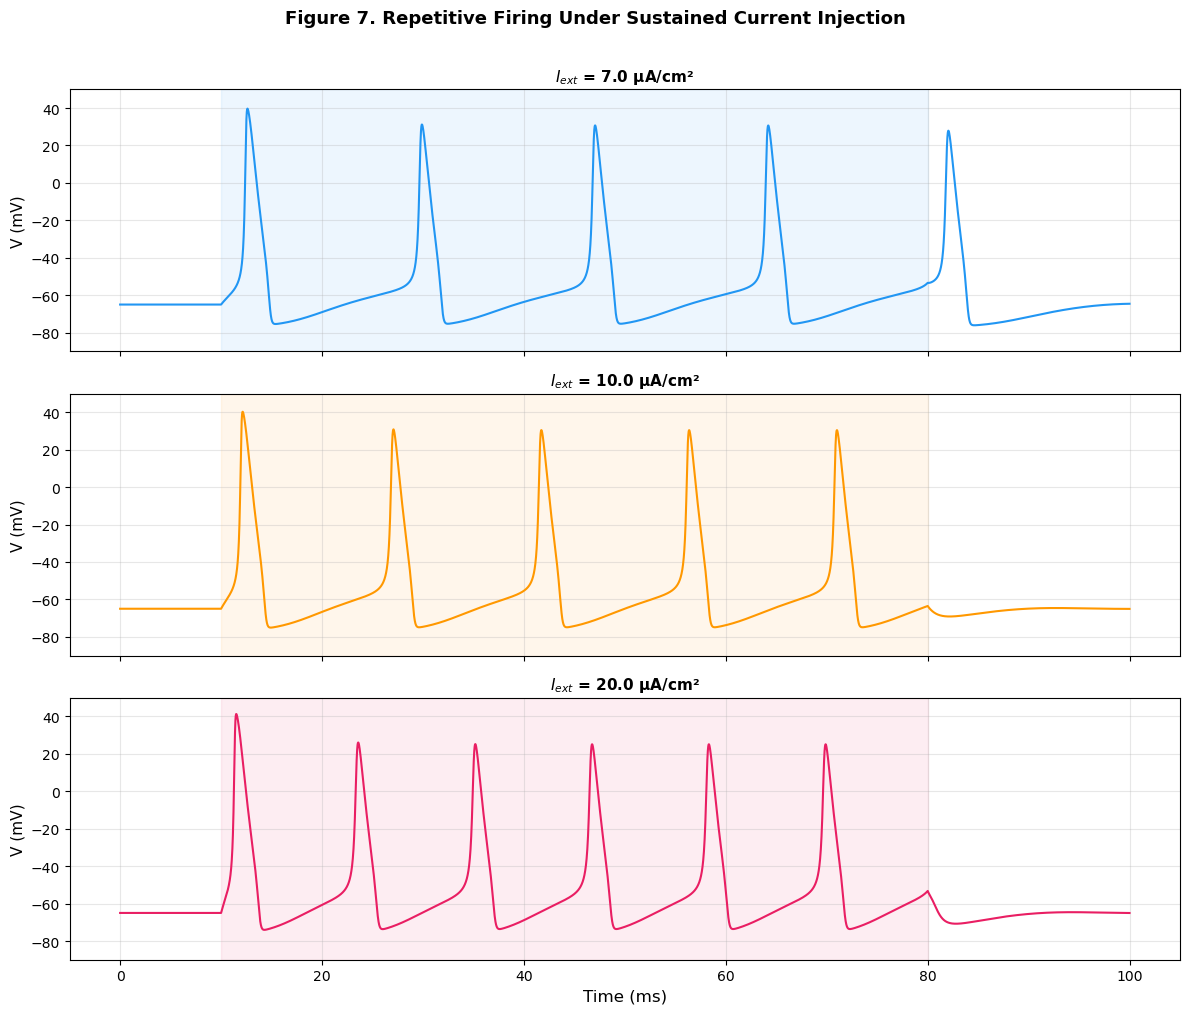

OBSERVATION: As the injected current increases, the neuron fires
more frequently. This frequency coding is fundamental to how
neurons transmit information in the nervous system.


In [26]:
# --- Repetitive firing with sustained current ---
hh = HodgkinHuxley()

fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

currents = [7.0, 10.0, 20.0]
colors = ['#2196F3', '#FF9800', '#E91E63']

for i, (I_amp, color) in enumerate(zip(currents, colors)):
    I_func = lambda t, amp=I_amp: amp if 10 <= t <= 80 else 0.0
    results = hh.simulate(t_max=100, I_ext_func=I_func)

    ax = axes[i]
    ax.plot(results['t'], results['V'], color=color, lw=1.5)
    ax.axvspan(10, 80, alpha=0.08, color=color)
    ax.set_ylabel('V (mV)', fontsize=11)
    ax.set_title(f'$I_{{ext}}$ = {I_amp} µA/cm²', fontsize=11, fontweight='bold')
    ax.set_ylim(-90, 50)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Time (ms)', fontsize=12)
plt.suptitle('Figure 7. Repetitive Firing Under Sustained Current Injection',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print("OBSERVATION: As the injected current increases, the neuron fires")
print("more frequently. This frequency coding is fundamental to how")
print("neurons transmit information in the nervous system.")

## 9. Threshold Behavior and the All-or-Nothing Principle

One of the most remarkable features of the action potential is its **all-or-nothing** character: a stimulus either triggers a full-amplitude action potential or fails entirely. There is a sharp **threshold** separating these two outcomes. Let us explore this computationally.

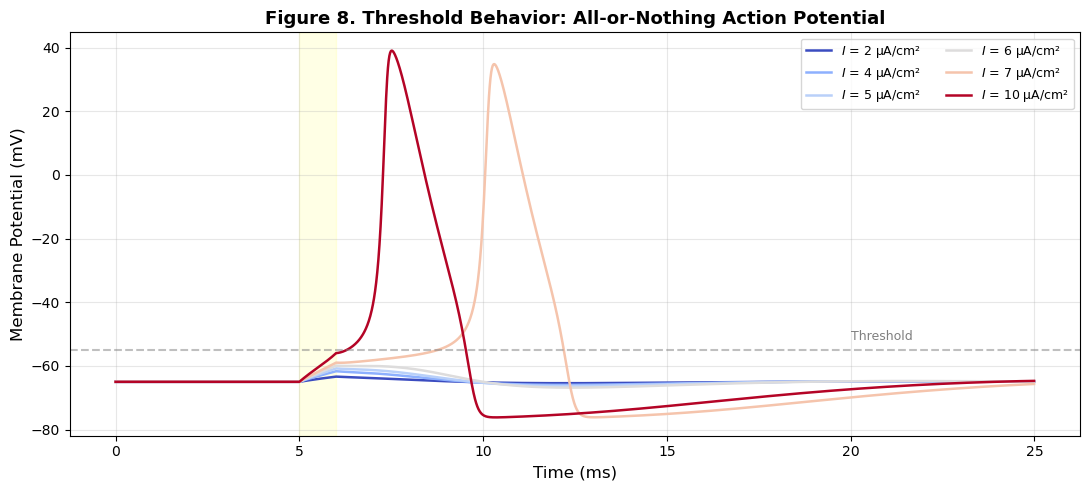

OBSERVATION: Stimuli below threshold (~6 µA/cm² for 1 ms) produce
only small, passive responses. Once threshold is crossed, a FULL
action potential is triggered regardless of how much above threshold
the stimulus is. This is the all-or-nothing principle.


In [27]:
# --- Threshold behavior: subthreshold vs suprathreshold ---
hh = HodgkinHuxley()

fig, ax = plt.subplots(figsize=(11, 5))

# Test a range of brief current pulses (1 ms duration)
amplitudes = [2, 4, 5, 6, 7, 10]
cmap = plt.cm.coolwarm
norm = plt.Normalize(vmin=min(amplitudes), vmax=max(amplitudes))

for amp in amplitudes:
    I_func = lambda t, a=amp: a if 5 <= t <= 6 else 0.0
    results = hh.simulate(t_max=25, I_ext_func=I_func)
    color = cmap(norm(amp))
    ax.plot(results['t'], results['V'], color=color, lw=1.8,
            label=f'$I$ = {amp} µA/cm²')

ax.axhline(y=-55, color='gray', linestyle='--', alpha=0.5)
ax.text(20, -52, 'Threshold', fontsize=9, color='gray')
ax.axvspan(5, 6, alpha=0.1, color='yellow')

ax.set_xlabel('Time (ms)', fontsize=12)
ax.set_ylabel('Membrane Potential (mV)', fontsize=12)
ax.set_title('Figure 8. Threshold Behavior: All-or-Nothing Action Potential', fontsize=13, fontweight='bold')
ax.legend(loc='upper right', fontsize=9, ncol=2)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("OBSERVATION: Stimuli below threshold (~6 µA/cm² for 1 ms) produce")
print("only small, passive responses. Once threshold is crossed, a FULL")
print("action potential is triggered regardless of how much above threshold")
print("the stimulus is. This is the all-or-nothing principle.")

## 10. Refractory Periods

After an action potential, the neuron enters a **refractory period** during which it is temporarily unable (or less able) to fire again:

- **Absolute refractory period** (~1-2 ms): No stimulus, however strong, can trigger another AP. Caused by Na⁺ channel inactivation ($h \approx 0$).
- **Relative refractory period** (~3-5 ms): A stronger-than-normal stimulus is required. Caused by lingering K⁺ channel activation ($n$ still elevated) and incomplete recovery of $h$.

This has important physiological consequences:
- It ensures **unidirectional propagation** of action potentials along the axon
- It sets an **upper limit** on firing frequency (~500-1000 Hz)

### Check Your Understanding: Threshold & Refractory Periods

**Q9.** A neuron is stimulated with two identical depolarizing pulses separated by 1.5 ms. The first pulse triggers a full action potential but the second does not. Why?

<details>
<summary>Click to reveal answer</summary>

The neuron is in its **absolute refractory period**. After the first AP:
- Na⁺ channels are **inactivated** ($h \approx 0$) — the inactivation gate has closed and needs time (~1–2 ms) to recover
- K⁺ channels are still **open** ($n$ is elevated), actively opposing depolarization
- Even an infinitely strong stimulus cannot trigger an AP because there simply aren't enough Na⁺ channels available to generate the regenerative inward current needed for depolarization

The neuron must wait for $h$ to recover (inactivation gates to reopen) before it can fire again. This is what creates the absolute refractory period.

</details>

---

**Q10.** What is the maximum firing frequency of a neuron if its absolute refractory period is 1 ms and its relative refractory period is an additional 3 ms?

<details>
<summary>Click to reveal answer</summary>

- **Theoretical maximum** (considering only absolute refractory period): $\frac{1}{1 \text{ ms}} = 1000$ Hz
- **Practical maximum** (including relative refractory period, where progressively stronger stimuli are needed): $\frac{1}{1 + 3 \text{ ms}} = 250$ Hz for normal-strength stimuli

In practice, most neurons fire at sustained rates of **10–200 Hz**, with brief bursts reaching up to **~500 Hz**. The refractory period is a key factor limiting this, along with synaptic and metabolic constraints.

</details>

---

**Q11.** Patients with **multiple sclerosis (MS)** experience demyelination of axons. How would you expect this to affect action potential propagation? *(Think about what myelin does.)*

<details>
<summary>Click to reveal answer</summary>

Myelin acts as an insulator that enables **saltatory conduction** — the action potential "jumps" between nodes of Ranvier, greatly increasing propagation speed (up to ~120 m/s in myelinated axons vs ~1 m/s in unmyelinated ones).

With **demyelination**:
1. **Conduction velocity decreases** dramatically — signals travel much more slowly
2. **Conduction may fail entirely** — the current leaks out through the damaged myelin sheath instead of reaching the next node
3. **Temporal dispersion** — signals in parallel axons arrive at different times, blurring the neural code

This explains MS symptoms: muscle weakness, sensory disturbances, fatigue, and cognitive difficulties — all traceable to slowed or blocked action potential propagation.

</details>

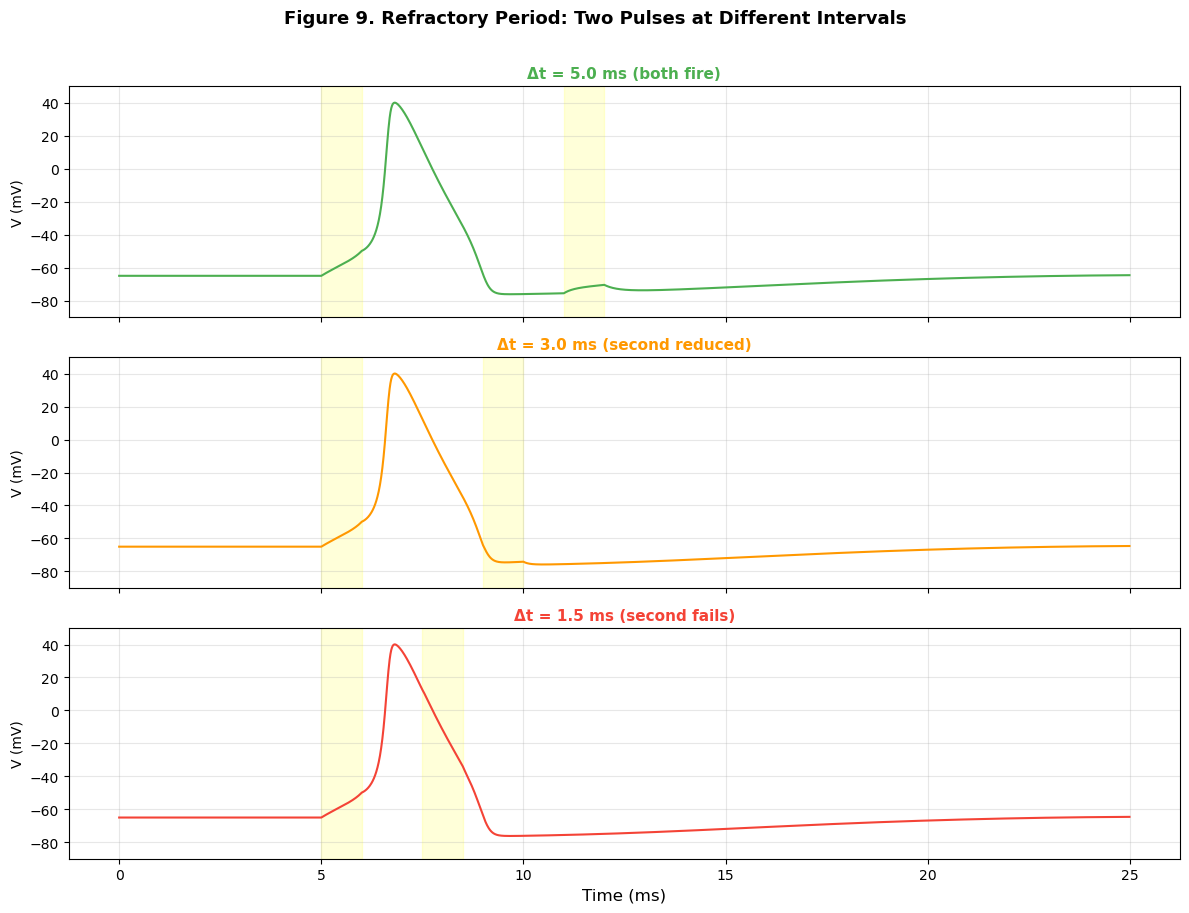

In [28]:
# --- Refractory period demonstration ---
hh = HodgkinHuxley()

fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
intervals = [5.0, 3.0, 1.5]  # ms between two pulses
labels = ['Δt = 5.0 ms (both fire)', 'Δt = 3.0 ms (second reduced)', 'Δt = 1.5 ms (second fails)']
colors_list = ['#4CAF50', '#FF9800', '#F44336']

for i, (dt_gap, label, col) in enumerate(zip(intervals, labels, colors_list)):
    # Two brief pulses
    t1_start, t1_end = 5.0, 6.0
    t2_start, t2_end = t1_end + dt_gap, t1_end + dt_gap + 1.0

    def I_func(t, s1=t1_start, e1=t1_end, s2=t2_start, e2=t2_end):
        if s1 <= t <= e1 or s2 <= t <= e2:
            return 15.0
        return 0.0

    results = hh.simulate(t_max=25, I_ext_func=I_func)
    ax = axes[i]
    ax.plot(results['t'], results['V'], color=col, lw=1.5)
    ax.axvspan(t1_start, t1_end, alpha=0.15, color='yellow')
    ax.axvspan(t2_start, t2_end, alpha=0.15, color='yellow')
    ax.set_ylabel('V (mV)', fontsize=10)
    ax.set_title(label, fontsize=11, fontweight='bold', color=col)
    ax.set_ylim(-90, 50)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Time (ms)', fontsize=12)
plt.suptitle('Figure 9. Refractory Period: Two Pulses at Different Intervals',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 11. Phase Plane Analysis

A powerful way to understand the dynamics of the HH model is through **phase plane** plots, which show the trajectory of the system in the space of two variables. Below we plot $V$ vs the Na⁺ conductance ($g_\text{Na}\,m^3h$) and vs the K⁺ conductance ($g_\text{K}\,n^4$) during an action potential. This reveals the characteristic **loop** trajectory of the action potential.

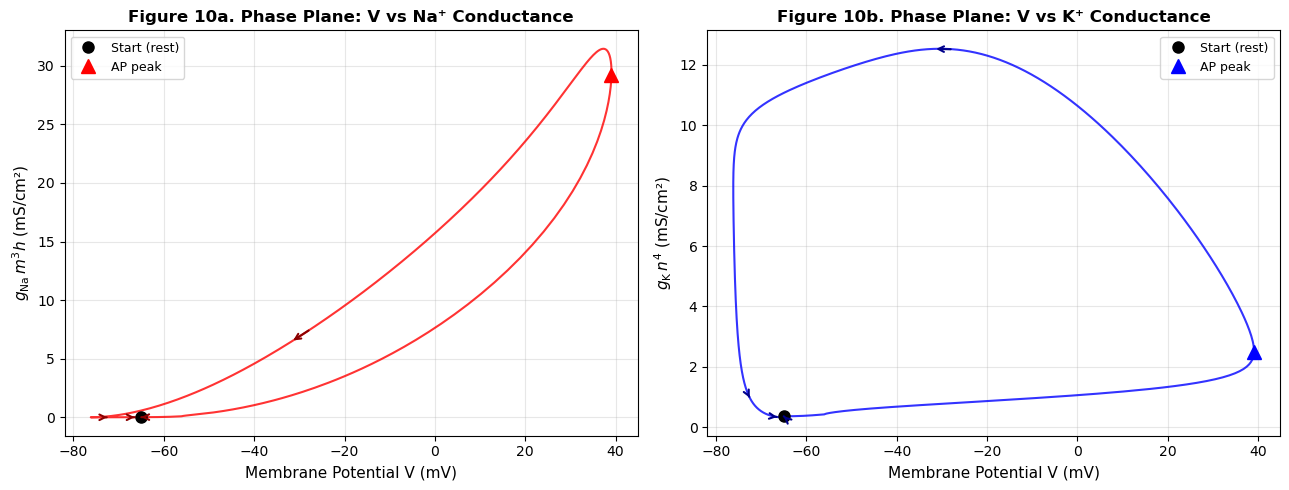

The Na⁺ conductance (left) shows a LOOP: it rises fast during
depolarization and falls as channels inactivate — a TRANSIENT response.
The K⁺ conductance (right) shows a COUNTER-CLOCKWISE loop:
it rises AFTER the voltage peaks and stays elevated during repolarization.


In [29]:
# --- Phase plane analysis ---
hh = HodgkinHuxley()
results = hh.simulate(t_max=30, I_ext_func=lambda t: 10.0 if 5 <= t <= 6 else 0.0)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# V vs Na+ conductance
ax = axes[0]
ax.plot(results['V'], results['g_Na_t'], 'r-', lw=1.5, alpha=0.8)
ax.plot(results['V'][0], results['g_Na_t'][0], 'ko', ms=8, label='Start (rest)')
# Mark peak
peak_idx = np.argmax(results['V'])
ax.plot(results['V'][peak_idx], results['g_Na_t'][peak_idx], 'r^', ms=10, label='AP peak')
# Add arrows to show direction
for frac in [0.15, 0.3, 0.5, 0.7]:
    idx = int(frac * len(results['t']))
    dx = results['V'][idx+10] - results['V'][idx]
    dy = results['g_Na_t'][idx+10] - results['g_Na_t'][idx]
    ax.annotate('', xy=(results['V'][idx+10], results['g_Na_t'][idx+10]),
                xytext=(results['V'][idx], results['g_Na_t'][idx]),
                arrowprops=dict(arrowstyle='->', color='darkred', lw=1.5))
ax.set_xlabel('Membrane Potential V (mV)', fontsize=11)
ax.set_ylabel(r'$g_\mathrm{Na}\,m^3h$ (mS/cm²)', fontsize=11)
ax.set_title('Figure 10a. Phase Plane: V vs Na⁺ Conductance', fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# V vs K+ conductance
ax = axes[1]
ax.plot(results['V'], results['g_K_t'], 'b-', lw=1.5, alpha=0.8)
ax.plot(results['V'][0], results['g_K_t'][0], 'ko', ms=8, label='Start (rest)')
ax.plot(results['V'][peak_idx], results['g_K_t'][peak_idx], 'b^', ms=10, label='AP peak')
for frac in [0.15, 0.3, 0.5, 0.7]:
    idx = int(frac * len(results['t']))
    ax.annotate('', xy=(results['V'][idx+10], results['g_K_t'][idx+10]),
                xytext=(results['V'][idx], results['g_K_t'][idx]),
                arrowprops=dict(arrowstyle='->', color='darkblue', lw=1.5))
ax.set_xlabel('Membrane Potential V (mV)', fontsize=11)
ax.set_ylabel(r'$g_\mathrm{K}\,n^4$ (mS/cm²)', fontsize=11)
ax.set_title('Figure 10b. Phase Plane: V vs K⁺ Conductance', fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("The Na⁺ conductance (left) shows a LOOP: it rises fast during")
print("depolarization and falls as channels inactivate — a TRANSIENT response.")
print("The K⁺ conductance (right) shows a COUNTER-CLOCKWISE loop:")
print("it rises AFTER the voltage peaks and stays elevated during repolarization.")

### DIY Exercises: Explore Further

**Exercise 1: Drug Simulation — Channel Blockers**

Tetrodotoxin (TTX, from puffer fish) blocks Na⁺ channels. TEA (tetraethylammonium) blocks K⁺ channels.

Simulate the effect of these drugs by reducing the maximum conductances:

<details>
<summary>Click for starter code</summary>

```python
# TTX effect: reduce g_Na
hh_ttx = HodgkinHuxley()
hh_ttx.g_Na = 12.0  # 10% of normal (120.0)

results_ttx = hh_ttx.simulate(t_max=30, I_ext_func=lambda t: 10.0 if 5 <= t <= 6 else 0.0)

plt.figure(figsize=(10, 4))
plt.plot(results_ttx['t'], results_ttx['V'], 'r-', lw=2, label='TTX (g_Na = 12)')
plt.plot(results['t'], results['V'], 'k--', lw=1, alpha=0.5, label='Normal')
plt.xlabel('Time (ms)')
plt.ylabel('V (mV)')
plt.title('Effect of TTX (Na⁺ channel blocker)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
```

</details>

<details>
<summary>Click to reveal what you should see</summary>

- **TTX (reduced $g_\text{Na}$)**: The action potential amplitude is reduced or eliminated entirely, depending on how much $g_\text{Na}$ is reduced. At ~50% block, the AP is smaller and slower. At ~90% block, no AP is generated at all — the neuron becomes inexcitable.
- **TEA (reduced $g_\text{K}$)**: The action potential fires but repolarization is *delayed* — the AP is broader (wider). The hyperpolarization phase is also reduced or absent. At extreme block, the membrane may not fully repolarize.

</details>

---

**Exercise 2: Temperature Dependence**

Ion channel kinetics speed up with temperature (approximately $Q_{10} \approx 3$, meaning rates triple for every 10°C increase). The standard HH parameters are for 6.3°C (squid axon in cold seawater).

<details>
<summary>Click for starter code</summary>

```python
# Temperature scaling factor
T_ref = 6.3    # °C (original HH temperature)
T_new = 37.0   # °C (human body temperature)
Q10 = 3.0
phi = Q10 ** ((T_new - T_ref) / 10.0)
print(f"Temperature scaling factor φ = {phi:.2f}")

# To apply: multiply all α and β rate constants by φ
# This makes the AP much faster and narrower at body temperature!
```

</details>

<details>
<summary>Click to reveal expected result</summary>

At 37°C, $\phi \approx 3^{3.07} \approx 28.4$. All rate constants are ~28× faster! The action potential becomes extremely brief (~0.1 ms instead of ~1 ms) and the maximum firing frequency increases dramatically. This is why mammalian neurons at body temperature can fire much faster than the squid axon at 6.3°C.

</details>

---

**Exercise 3: Frequency–Current (f–I) Curve**

A key property of neurons is the relationship between injected current and firing rate. Write code to sweep $I_\text{ext}$ from 0 to 30 µA/cm² and count the number of action potentials in a 100 ms window.

<details>
<summary>Click for hint</summary>

```python
# Count spikes by detecting threshold crossings (V crossing -20 mV upward)
def count_spikes(V, threshold=-20):
    crossings = np.diff((V > threshold).astype(int))
    return np.sum(crossings == 1)
```
Plot the number of spikes (or frequency = spikes / duration) vs. $I_\text{ext}$ to get the **f–I curve**.

</details>

<details>
<summary>Click to reveal what you should see</summary>

The f–I curve shows:
1. **Below threshold** (~6 µA/cm²): zero firing — no APs
2. **At threshold**: firing begins abruptly (this is a **bifurcation** in dynamical systems language)
3. **Above threshold**: firing frequency increases with current, initially steeply then more gradually
4. **Saturation**: at very high currents, the firing rate plateaus because the refractory period sets a maximum

This S-shaped (or ramp-shaped) curve is called a **Type II** neural excitability curve, characteristic of the HH model. It shows how neurons convert analog input (current amplitude) into a digital-like code (spike frequency).

</details>

In [30]:
# ── DIY: Implement the exercises above ─────────────────────
# Use this cell to experiment. The HodgkinHuxley class from
# the earlier cell is available.

# --- Exercise 1: Channel blockers ---
# (uncomment and modify)
# hh_ttx = HodgkinHuxley()
# hh_ttx.g_Na = 12.0   # TTX: 10% of normal
# results_ttx = hh_ttx.simulate(t_max=30,
#     I_ext_func=lambda t: 10.0 if 5 <= t <= 6 else 0.0)
# plt.figure(figsize=(10, 4))
# plt.plot(results_ttx['t'], results_ttx['V'], 'r-', lw=2)
# plt.title('Effect of TTX')
# plt.show()

# --- Exercise 2: Temperature ---
# T_ref, T_new, Q10 = 6.3, 37.0, 3.0
# phi = Q10 ** ((T_new - T_ref) / 10.0)
# print(f"φ = {phi:.2f}")

# --- Exercise 3: f-I curve ---
# def count_spikes(V, threshold=-20):
#     return np.sum(np.diff((V > threshold).astype(int)) == 1)
#
# currents = np.arange(0, 31, 1.0)
# spike_counts = []
# for I_amp in currents:
#     res = hh.simulate(t_max=100,
#         I_ext_func=lambda t, a=I_amp: a if 10 <= t <= 90 else 0.0)
#     spike_counts.append(count_spikes(res['V']))
#
# plt.figure(figsize=(8, 5))
# plt.plot(currents, spike_counts, 'ko-', lw=2)
# plt.xlabel('Injected Current (µA/cm²)')
# plt.ylabel('Number of Spikes (in 80 ms)')
# plt.title('f–I Curve')
# plt.grid(True, alpha=0.3)
# plt.show()

## 12. Going Deeper

### Extensions of the HH model

The basic HH model can be extended in many directions:

- **Spatial propagation**: Add a diffusion term to simulate action potential propagation along an axon (cable equation)
- **Temperature dependence**: Ion channel kinetics speed up with temperature ($Q_{10} \approx 3$)
- **Synaptic transmission**: Add conductance-based synaptic inputs to model networks
- **Channel blockers**: Simulate the effect of drugs like TTX (tetrodotoxin, blocks Na⁺) or TEA (tetraethylammonium, blocks K⁺)
- **Stochastic channels**: Replace deterministic gating with Markov chain models to capture channel noise
- **Realistic morphology**: Use compartmental models (e.g., NEURON simulator) to model dendritic trees

### Key references

1. **Hodgkin, A.L. & Huxley, A.F.** (1952). A quantitative description of membrane current and its application to conduction and excitation in nerve. *J. Physiol.* 117:500–544. [The original paper]
2. **Izhikevich, E.M.** (2007). *Dynamical Systems in Neuroscience: The Geometry of Excitability and Bursting*. MIT Press. [Excellent textbook with geometric intuition]
3. **Dayan, P. & Abbott, L.F.** (2001). *Theoretical Neuroscience*. MIT Press. [Standard computational neuroscience textbook]
4. **Gerstner, W. et al.** *Neuronal Dynamics* — free online textbook: https://neuronaldynamics.epfl.ch/online/Ch2.S2.html
5. **3Blue1Brown** — Differential equations, a tourist's guide: https://youtu.be/p_di4Zn4wz4

### Useful resources
- APMonitor — Solve Differential Equations: https://apmonitor.com/pdc/index.php/Main/SolveDifferentialEquations
- UiO course notes on HH model: https://www.uio.no/studier/emner/matnat/fys/FYS4715/h20/CourseMaterial/Projects/HodgkinHuxley/hh_uio.pdf
- HH model Python gist: https://gist.github.com/giuseppebonaccorso/60ce3eb3a829b94abf64ab2b7a56aaef